In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

colors = sns.color_palette('colorblind')

# Load data

In [2]:
city_df = pd.read_csv('data/city_ranking.csv')
dynamics_df = pd.read_csv('data/monthly_dynamics.csv')
segmentation_df = pd.read_csv('data/segmentation.csv')
is_late_order_df = pd.read_csv('data/is_late_order.csv')
order_diversity_df = pd.read_csv('data/order_diversity.csv')

## City translation

The original data set is not in English, so we do the translation first

In [ ]:
# Translate city names into English
city_translation = {
    'Красноярск': 'Krasnoyarsk',
    'Ростов-на-Дону': 'Rostov-on-Don',
    'Самара': 'Samara',
    'Ижевск': 'Izhevsk',
    'Челябинск': 'Chelyabinsk',
    'Нижний Новгород': 'Nizhny Novgorod',
    'Омск': 'Omsk',
    'Екатеринбург': 'Yekaterinburg',
    'Уфа': 'Ufa',
    'Казань': 'Kazan',
    'Новосибирск': 'Novosibirsk',
    'Волгоград': 'Volgograd',
    'Воронеж': 'Voronezh',
    'Москва': 'Moscow',
    'Санкт-Петербург': 'Saint Petersburg',
    'Саратов': 'Saratov',
    'Краснодар': 'Krasnodar',
    'Тюмень': 'Tyumen',
    'Пермь': 'Perm',
    'Тольятти': 'Tolyatti',
}

# Translate
translate_dfs = [city_df,dynamics_df,segmentation_df,is_late_order_df]
for df in translate_dfs:
    df['customer_city'] = df['customer_city'].map(city_translation)

# Cohort analysis

## Retention

In [4]:
# Wide format of retention data for heatmap visualization
retention_wide = pd.pivot_table(dynamics_df, 
                                index=['customer_city', 'cohort'], 
                                columns=['which_month'], 
                                values=['retention']).reset_index()
retention_wide.columns = [c_name[0] if c_name[0] != 'retention' else i-2 for i, c_name in enumerate(retention_wide.columns)]

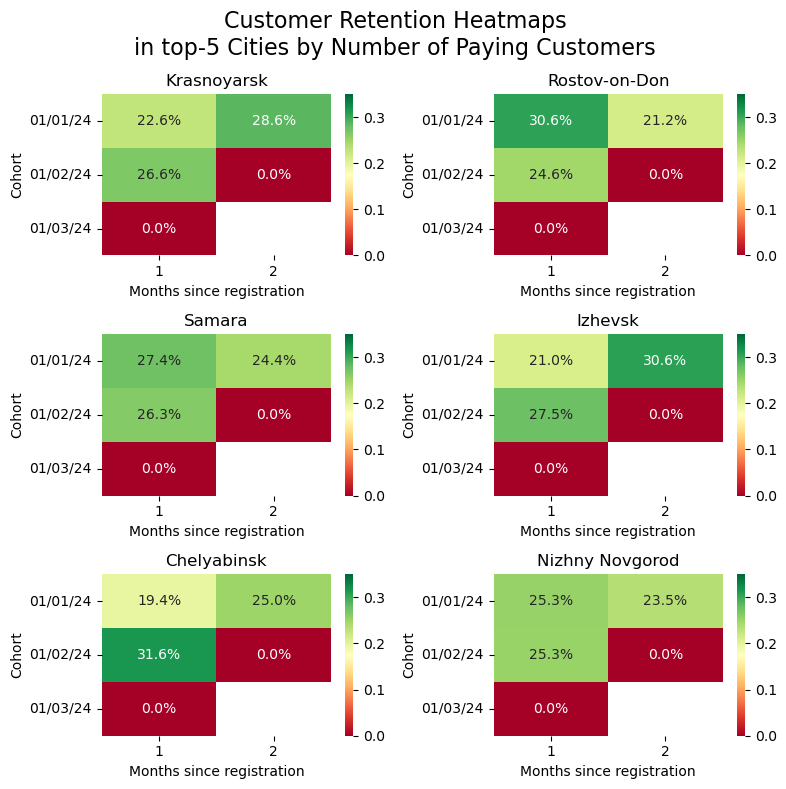

In [5]:
# Top 5 cities by number of paying customers
top_cities = city_df.query('rank_paying_customers_count <= 5').customer_city

# Heatmaps
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.flatten()

for i, city in enumerate(top_cities):
    city_data = retention_wide[retention_wide['customer_city'] == city]\
        .set_index('cohort')\
            .drop(columns=['customer_city',0,3])
    
    sns.heatmap(city_data, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=0.35, ax=axes[i])
    axes[i].set_title(f'{city}')
    axes[i].set_xlabel('Months since registration')
    axes[i].set_ylabel('Cohort')
plt.suptitle('Customer Retention Heatmaps\nin top-5 Cities by Number of Paying Customers', fontsize=16)
plt.tight_layout()
plt.show()

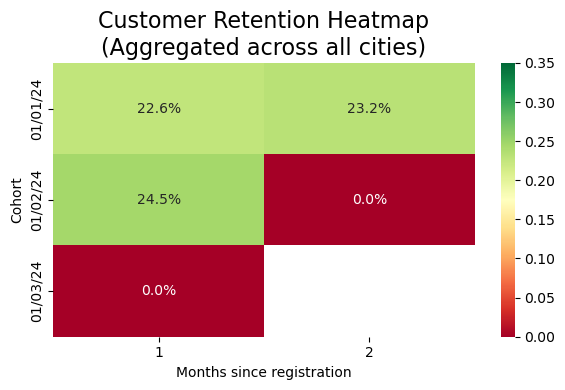

In [6]:
# Aggregated retention
retention_agg = dynamics_df\
    .groupby(['cohort', 'which_month'])\
        .retention.mean()\
            .reset_index()
retention_agg = retention_agg.pivot(index='cohort', columns='which_month', values='retention')
retention_agg.drop(columns=[0, 3], inplace=True)

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(retention_agg, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=0.35)
plt.title('Customer Retention Heatmap\n(Aggregated across all cities)', fontsize=16, loc='center')
plt.xlabel('Months since registration')
plt.ylabel('Cohort')
plt.tight_layout()
plt.show()

- Months 0 and 3 were excluded from the analysis: month 0 retention is systematically underestimated since customers register throughout the month and have limited time to make a purchase, while month 3 data is incomplete given the observation window ends in March 2024.

- Across all cities, month-1 and month-2 retention rates are broadly consistent, ranging from 20% to 30%. Notably, month-2 retention frequently exceeds month-1, which may reflect the nature of the product category - customers who return tend to do so on a monthly repurchase cycle rather than immediately. With only two retention periods available, it is premature to draw firm conclusions about long-term loyalty. A longer observation window is needed to assess whether retention stabilises, grows, or declines over time.

## Revenue

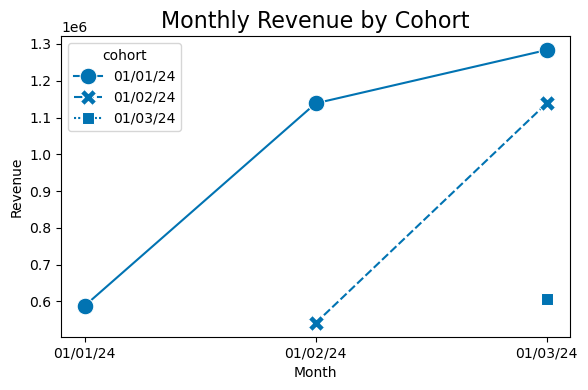

In [7]:
# Monthly Revenue by Cohort
plt.figure(figsize=(6, 4))
sns.lineplot(data=dynamics_df, x='event_month', y='revenue', 
             style='cohort', markers=True, dashes=True,
             color=colors[0], errorbar=None, markersize=12)
plt.title('Monthly Revenue by Cohort', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

Each cohort shows a clear upward revenue trend month over month, with all three cohorts generating comparable revenue in their respective first and second active months. This consistency across cohorts suggests a stable customer spending pattern rather than a one-time effect. The January cohort, having the longest observation window, shows the strongest absolute revenue growth reaching ~1.3M by March. The key growth lever going forward is increasing cohort size: with revenue per cohort remaining stable, acquiring more customers each month will directly compound total revenue.

## Cohort size

In [8]:
# Compute cohort size manually because need to drop duplicates for correct calculations
cohort_size_df = dynamics_df[['customer_city','cohort', 'cohort_size']]\
    .drop_duplicates()\
        .groupby(['cohort'])\
            .cohort_size.sum()\
                .reset_index()

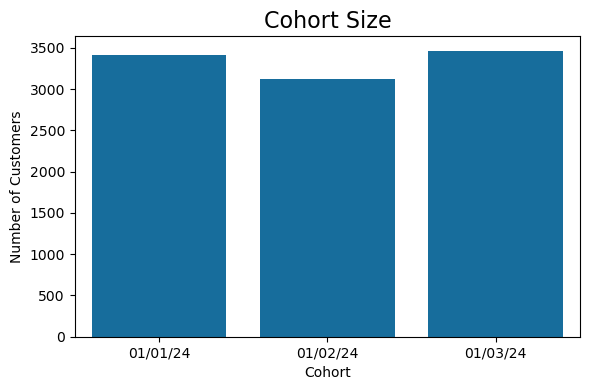

In [9]:
# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=cohort_size_df, 
            x='cohort', y='cohort_size',
            color=colors[0],
            legend=False, errorbar=None)
plt.title('Cohort Size', fontsize=16)
plt.xlabel('Cohort')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Cohort sizes are relatively stable across the three months, ranging from 150 to 165 customers. February shows a slight dip compared to January and March, which may reflect seasonal variation or a slowdown in acquisition efforts. The consistency in cohort size is a neutral signal. It indicates the business is maintaining its acquisition pace but not growing it. To scale revenue, the business should prioritise increasing monthly new customer acquisition alongside maintaining the current retention levels

# City ranking analysis

## Number of Paying Customers

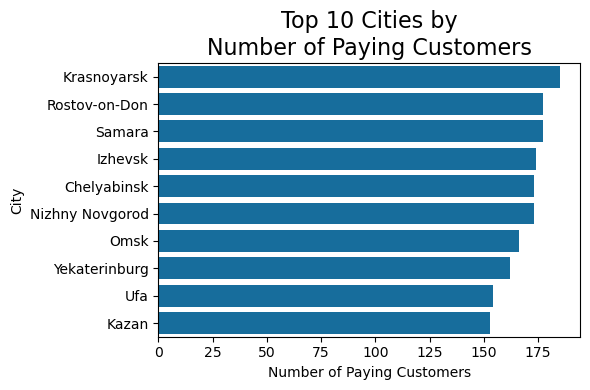

In [10]:
# Top 10 Cities by Number of Paying Customers
top_n_customers = city_df.query('rank_paying_customers_count <= 10')
plt.figure(figsize=(6, 4))
sns.barplot(data=top_n_customers, x='paying_customers_count', y='customer_city', color=colors[0])
plt.title('Top 10 Cities by\nNumber of Paying Customers', fontsize=16)
plt.xlabel('Number of Paying Customers')
plt.ylabel('City')
plt.tight_layout()
plt.show()

## Customers vs Revenue

In [11]:
# Remove the row where customer_city is NaN
city_df_not_nan = city_df.loc[city_df.customer_city.notna()]

In [12]:
# Plot adjustments
# Scale redemption rate to make size differences visible
size_scaled = (city_df_not_nan["redemption_rate"] - city_df_not_nan["redemption_rate"].min()) / \
              (city_df_not_nan["redemption_rate"].max() - city_df_not_nan["redemption_rate"].min())
bubble_size = 100 + size_scaled * 900

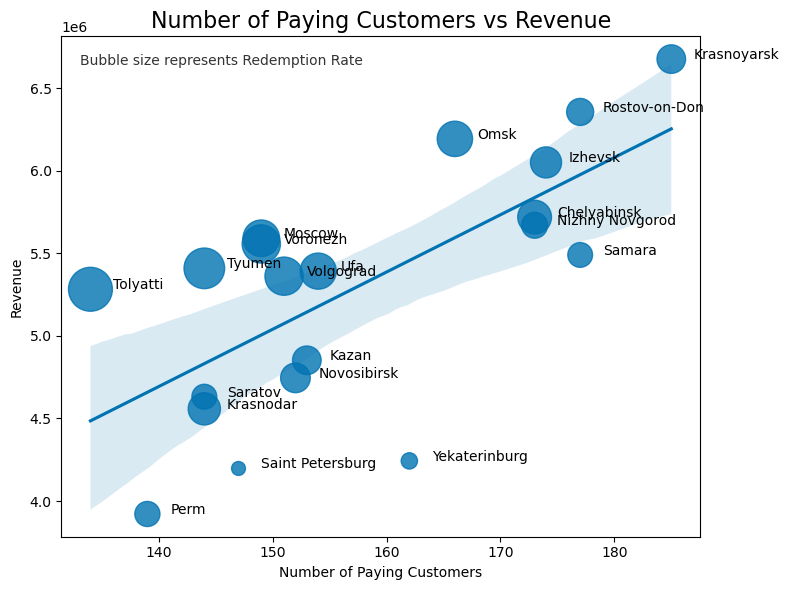

In [13]:
# Bubble plot of number of paying customers vs revenue delivered + redemption rate
plt.figure(figsize=(8, 6))
ax = sns.regplot(data=city_df_not_nan,
                 x='paying_customers_count', y='revenue', 
                 scatter_kws={"s": bubble_size},
                 scatter=True, color=colors[0])

# Annotate each point with the city name
for _, row in city_df_not_nan.iterrows():
    ax.text(
      row["paying_customers_count"] + 2,
      row["revenue"],
      row["customer_city"],
      horizontalalignment="left",
      size="medium",
      color="black"
      )
plt.title('Number of Paying Customers vs Revenue', fontsize=16)
ax.text(0.25, 0.95, 'Bubble size represents Redemption Rate', 
        ha='center', va='center', color='black', alpha=0.8,
        transform=ax.transAxes, fontsize=10)
plt.xlabel('Number of Paying Customers')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

The scatter plot reveals two distinct city clusters worth investigating:

- **Underperforming cities (Perm, Saint Petersburg, Ekaterinburg):** These cities have below-average customer counts and generate less revenue than the regression line would predict. The small bubble size indicates a low redemption rate, suggesting customers frequently return or reject orders. This warrants further investigation. Potential causes include: logistics issues, longer delivery times, or stronger local competition offering better value. Improving redemption rates in these cities could unlock significant revenue gains without acquiring new customers.

- **High-loyalty, low-volume cities (Tolyatti, Tyumen, Volgograd, Ufa, Moscow, Voronezh):** Despite having fewer customers than average, these cities generate revenue close to or above the trend line, driven by high redemption rates. Tolyatti is a striking example: ~130 customers generate comparable revenue to Samara, which has roughly 1.5x more customers. This suggests strong product-market fit and customer satisfaction in these cities. The key growth lever here is customer acquisition: increasing the customer base while maintaining current redemption levels would likely yield a disproportionate revenue uplift.

# Segmentation analysis

## Segment Size

In [14]:
# Grouped segmentation data by city, cohort, and segment
segmentation_grouped = segmentation_df.groupby(['customer_city','segment'])\
      .agg({'customer_id':'count', 
            'orders_count':'sum',
            'avg_delivery_days':'mean'})\
                  .reset_index()\
                        .rename(columns={'customer_id':'unique_customers_count'})\
                              .fillna(0)      

In [15]:
# Use consistent colors for segments across plots
# We'll reuse it later
segment_colors = {'new': colors[1], 
                  'inactive': colors[2], 
                  'one_time': colors[3], 
                  'regular': colors[4]}

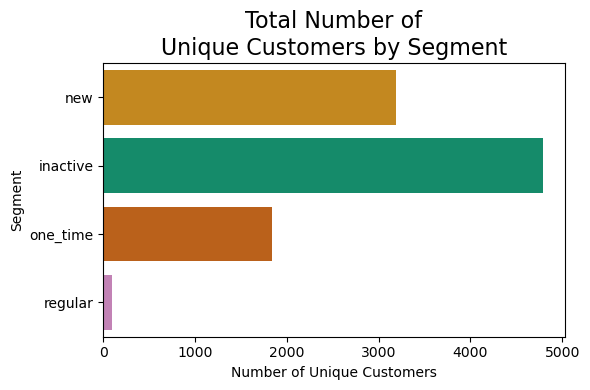

In [16]:
# Total Number of Unique Customers by Segment
plt.figure(figsize=(6, 4))
sns.barplot(data=segmentation_grouped, x='unique_customers_count', y='segment', hue='segment',
            estimator='sum', errorbar=None, 
            palette=segment_colors, # use different colors to be consistent with the following plots
            order=['new','inactive','one_time','regular'])
plt.title('Total Number of\nUnique Customers by Segment', fontsize=16)
plt.xlabel('Number of Unique Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()

The majority of registered customers fall into the Inactive and New segments, while paying customers (One-time and Regular) represent a small minority. This highlights a significant conversion gap: most registered users never complete a purchase. Converting even a fraction of Inactive customers into One-time buyers represents the highest-leverage growth opportunity available without additional acquisition spend

## Top-5 & Bottom-5 Cities Segment Distribution

In [17]:
# Top and Bottom 5 Cities by Number of Paying Customers
top5_cities = city_df_not_nan.query('rank_paying_customers_count <= 5').customer_city

max_rank = city_df_not_nan['rank_paying_customers_count'].max()
bottom5_cities = city_df_not_nan.query(f'rank_paying_customers_count >= {max_rank} - 4').customer_city

In [18]:
# Total number of customers by segment in top and bottom 5 cities
pivot = segmentation_grouped[segmentation_grouped['customer_city'].isin(top5_cities.tolist() + bottom5_cities.tolist())]\
         .pivot_table(index='customer_city', columns='segment',
                      values='unique_customers_count', aggfunc='sum', fill_value=0)

pivot['total'] = pivot.sum(axis=1)

pivot = pivot.merge(city_df[['customer_city', 'rank_paying_customers_count']], 
                    left_index=True, right_on='customer_city')\
             .rename(columns={'rank_paying_customers_count': 'paying_customers'})
             
pivot = pivot.sort_values(['total', 'paying_customers'], ascending=True)
pivot = pivot.drop(columns=['total', 'paying_customers'])
pivot = pivot.set_index('customer_city')

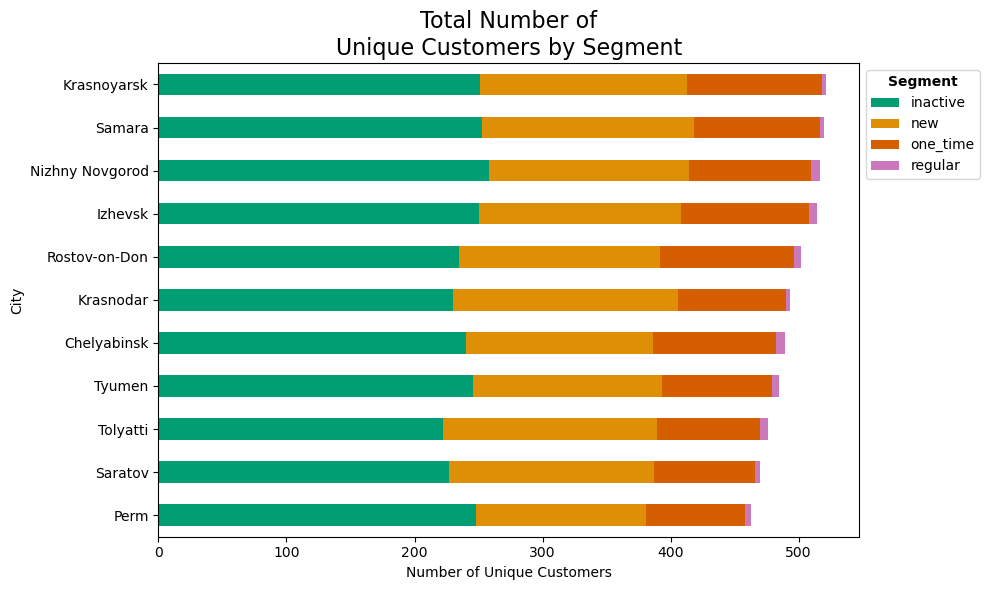

In [19]:
# Plot
pivot.plot(kind='barh', stacked=True, figsize=(10, 6), color=segment_colors)
plt.title('Total Number of\nUnique Customers by Segment', fontsize=16)
plt.xlabel('Number of Unique Customers')
plt.ylabel('City')
leg = plt.legend(title='Segment', bbox_to_anchor=(1, 1), loc='upper left')
leg.get_title().set_fontweight('bold')
plt.tight_layout()
plt.show()

The segment composition is broadly consistent across cities, with Inactive and New customers dominating in all cases. However, the share of One-time and Regular customers 
varies slightly. Cities like Krasnoyarsk and Samara show a marginally higher proportion of paying customers relative to their total registered base. No city shows a dramatically different profile, suggesting that the conversion problem is systemic rather than city-specific

## Order count, Delivery time, Revenue

By definition, new and inactive customers haven't made any orders, so `orders_count`, `avg_delivery_days`, and `revenue` are 0 for all of them. That's why we'll drop these rows and will only consider one-time and regular customers

In [20]:
# Select only one_time & regular customers
segmentation_ot_reg = segmentation_df.copy()
segmentation_ot_reg = segmentation_ot_reg.loc[segmentation_ot_reg['segment'].isin(['one_time','regular'])]

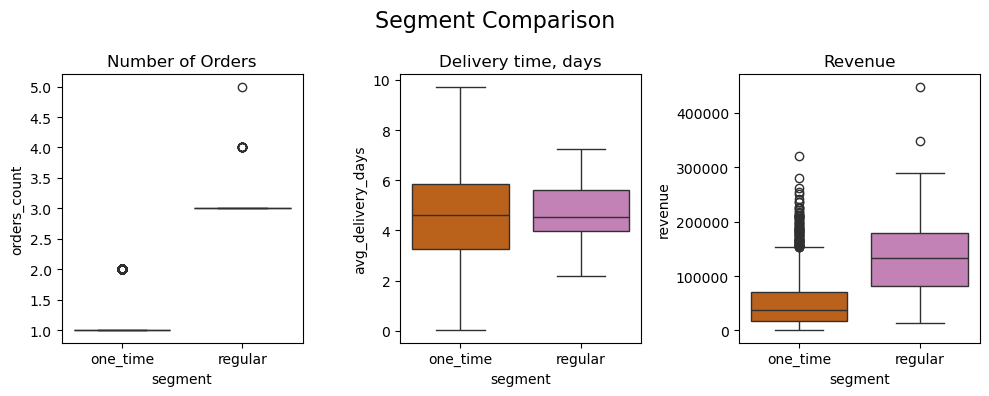

In [21]:
# Plot
fig, axes = plt.subplots(1,3, figsize=(10,4))
axes = axes.flatten()
y_values = {'orders_count': 'Number of Orders', 
            'avg_delivery_days': 'Delivery time, days', 
            'revenue': 'Revenue'}

for i, (y_val, y_name) in enumerate(y_values.items()):
    sns.boxplot(data=segmentation_ot_reg, 
                x='segment', y=y_val, hue='segment',
                palette=segment_colors,
                ax=axes[i],
                )
    axes[i].set_title(y_name)

plt.suptitle('Segment Comparison', fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
# T-test
dependent_var = ['orders_count', 'avg_delivery_days', 'revenue']

for dv in dependent_var:
    print('\n' + '=' * 20 + dv + '=' * 20)
    one_time_dat = segmentation_ot_reg.loc[segmentation_ot_reg['segment']=='one_time', dv]
    regular_dat = segmentation_ot_reg.loc[segmentation_ot_reg['segment']=='regular', dv]
    res = pg.ttest(one_time_dat, regular_dat)
    print(res)


====================orders_count====================
                T       dof alternative         p_val            CI95  \
T_test -47.580911  105.3696   two-sided  4.723778e-73  [-2.04, -1.88]   

         cohen_d  power BF10  
T_test  4.908194    1.0  inf  

====================avg_delivery_days====================
               T         dof alternative     p_val           CI95   cohen_d  \
T_test -1.026053  120.367914   two-sided  0.306924  [-0.38, 0.12]  0.072105   

           power   BF10  
T_test  0.105842  0.192  

====================revenue====================
                T        dof alternative         p_val  \
T_test -11.514151  98.760805   two-sided  5.852588e-20   

                           CI95  cohen_d  power       BF10  
T_test  [-103680.57, -73198.37]  1.85212    1.0  2.262e+26  


We compared one-time and regular customers across three metrics using Welch's t-test

- **Order Count:** Regular customers placed significantly more orders than one-time customers (p < 0.001, Cohen's d = 4.91). This is expected by segment definition, but the effect size confirms that regular customers are substantially more engaged

- **Average Delivery Time:** No significant difference was found between segments (p = 0.307, Cohen's d = 0.07). This is an important finding - delivery speed does not explain why some customers return and others do not. Customer retention is likely driven by other factors such as product quality, pricing, or overall experience

- **Revenue:** Regular customers generate significantly higher revenue than one-time customers (p < 0.001, Cohen's d = 1.85). On average, regular customers spend ~88,000 more than one-time customers. Combined with the delivery finding, this suggests that converting one-time buyers into regular customers is the highest-leverage growth opportunity. And logistics improvements alone are unlikely to achieve this

## Delivery time by cities

This analysis is for delivered orders only!

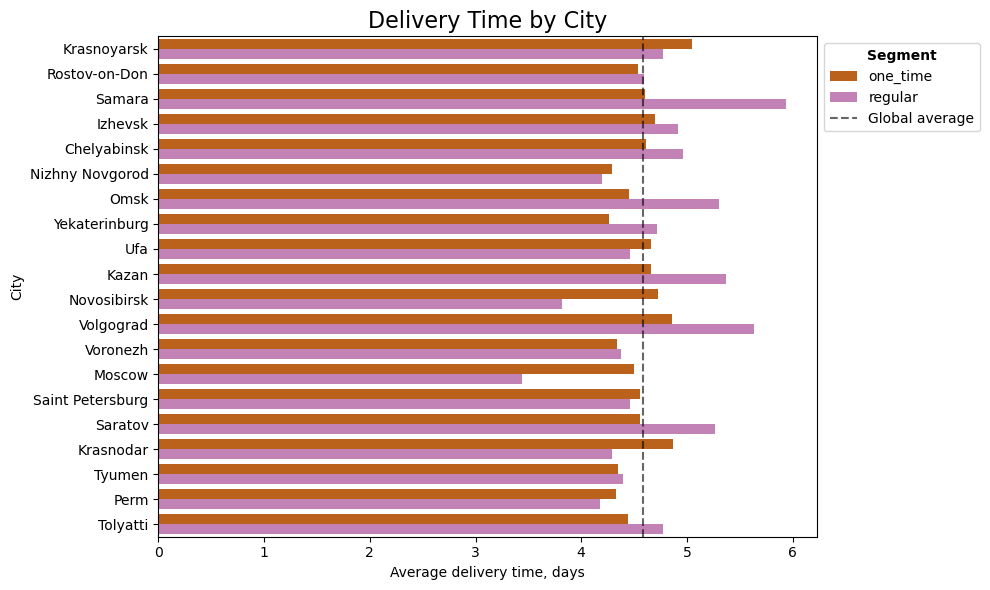

In [23]:
# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=segmentation_ot_reg, x='avg_delivery_days', y='customer_city', hue='segment', errorbar=None, palette=segment_colors,
            order=city_df_not_nan.sort_values('rank_paying_customers_count').customer_city # order by rank of paying customers count
            )

plt.axvline(segmentation_ot_reg.avg_delivery_days.mean(), color='black', alpha=0.6, ls='dashed', label='Global average')
plt.xlabel('Average delivery time, days')
plt.ylabel('City')
leg = plt.legend(title='Segment', bbox_to_anchor=(1, 1), loc='upper left')
leg.get_title().set_fontweight('bold')
plt.title('Delivery Time by City', fontsize=16)
plt.tight_layout()
plt.show()

Average delivery time is consistent across cities and segments, ranging from approximately 4 to 5 days, with most cities clustering around the global average. Crucially, there is no meaningful difference in delivery time between One-time and Regular customers, confirming the earlier t-test finding (p = 0.307)

This result is particularly relevant for the underperforming cities identified in the city ranking analysis (Perm, Saint Petersburg, Ekaterinburg). Despite their low redemption rates and below-expected revenue, delivery times in these cities are not notably longer than average. This rules out logistics speed as the primary cause of underperformance and shifts attention toward other potential factors, like pricing, product assortment, or competitive dynamics in those markets

## Late orders

In [24]:
# Merge two datasets to get info about orders & customers segment
paying_customers_df = pd.merge(is_late_order_df,
                               segmentation_df[['customer_id', 'customer_city', 'cohort','segment']], 
                               how='left', on=['customer_id','customer_city'])

# Compute how late orders are
paying_customers_lateness = paying_customers_df.groupby(['customer_city','order_status','cohort','segment'], as_index=False).how_late_days.mean()

Here we will consider only Delivered and In Transit orders because they are already complete or still in progress. We don't know when returned orders were returned, so we are not considering them here. Note: delays for the In Transit orders are based on "today" date which is March 31, 2024. So, these values indicate "at least this many days late" rather than the exact value.

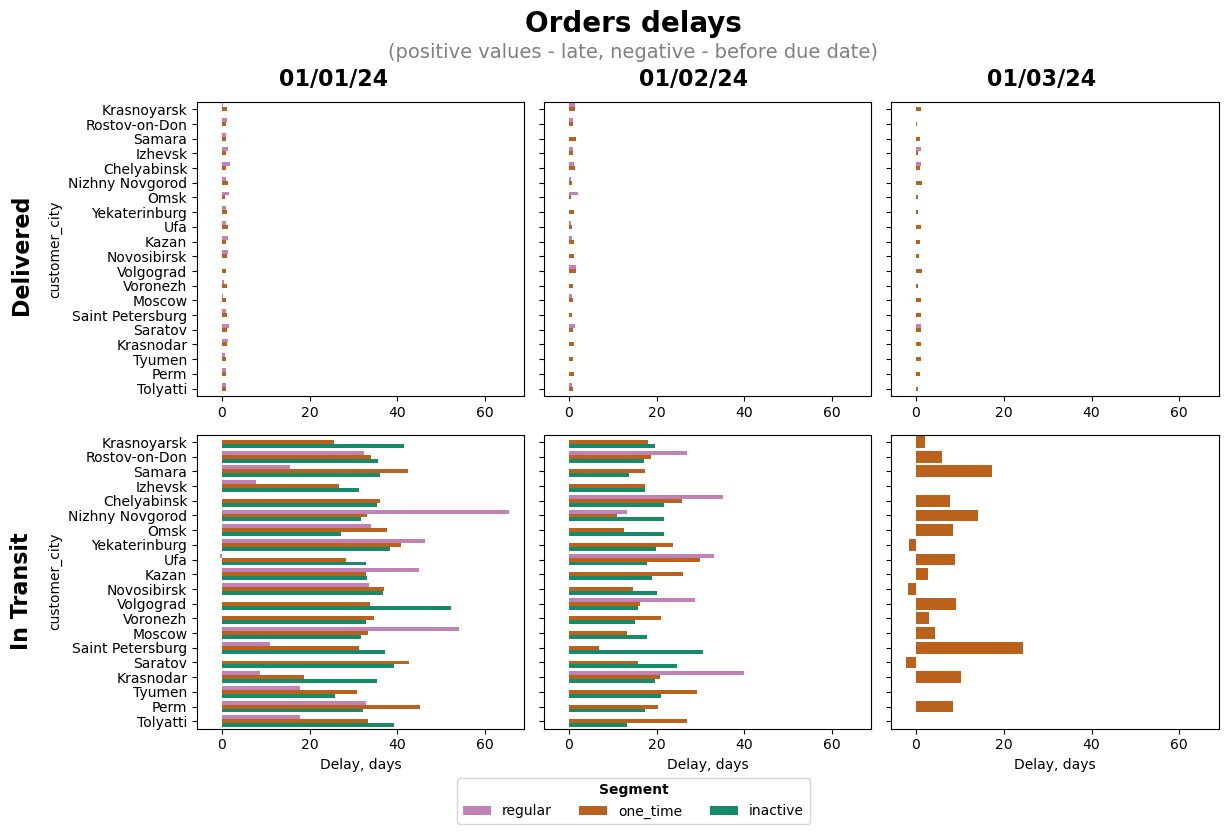

In [25]:
# Plot
order_statuses = ['Delivered', 'In Transit']
segments = ['regular', 'one_time', 'inactive']

all_cities = city_df_not_nan.sort_values('rank_paying_customers_count').customer_city

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
cohorts = paying_customers_lateness.cohort.unique()

for i_stat, stat in enumerate(order_statuses):
    for i_coh, coh in enumerate(cohorts):
        dat = paying_customers_lateness.loc[
            (paying_customers_lateness['cohort'] == coh) &
            (paying_customers_lateness['order_status'] == stat) &
            (paying_customers_lateness['segment'].isin(segments))
        ]

        sns.barplot(
            data=dat, x='how_late_days', y='customer_city',
            hue='segment', ax=axes[i_stat, i_coh],
            palette=segment_colors, hue_order=segments,
            order=all_cities,
            errorbar=None
        )
        axes[i_stat, i_coh].tick_params(labelbottom=True)
        axes[i_stat, i_coh].set_xlabel('Delay, days')

        # keep only one legend for the whole figure
        if i_coh == 0 & i_stat==0:
            handles, labels = axes[i_stat, i_coh].get_legend_handles_labels()
        axes[i_stat, i_coh].get_legend().remove()

# Legend
leg = fig.legend(handles, labels, title='Segment', loc='center',
            bbox_to_anchor=(0.5, -0.02), ncol=3)
leg.get_title().set_fontweight('bold')

# Subplot labels
for i in range(3):
    fig.text([0.25, 0.55, 0.84][i], 1.01, cohorts[i], 
             fontsize=16, fontweight='bold', ha='center', va='center')
for i in range(2):
    fig.text(-.01, [0.76, 0.28][i], order_statuses[i], 
             rotation='vertical', fontsize=16, fontweight='bold', 
             ha='center', va='center')

# Title
fig.text(0.5, 1.09, 'Orders delays',
         fontsize=20, fontweight='bold', ha='center', va='center')
fig.text(0.5, 1.05,
         '(positive values - late, negative - before due date)',
         fontsize=14, color='grey', ha='center', va='center')
plt.tight_layout()
plt.show()

- **Inactive and one-time customers have undelivered orders, not just low engagement.** A substantial share of customers classified as Inactive or One-time have orders that are still In Transit, with delays ranging from 10 to 40+ days beyond the estimated delivery date. This means their segment classification is partially misleading: these customers may not be disengaged. Instead, they are simply waiting for orders that have not arrived yet. Any reactivation campaign targeting Inactive customers should first account for this group, as reaching out to customers with unresolved deliveries risks damaging trust further rather than reactivating them

- **Regular customers show a selection bias effect.** The Regular segment has notably fewer cities with severely delayed orders compared to One-time and Inactive segments. This is unlikely to reflect better logistics for loyal customers. Contrary, it may suggest that customers who consistently receive orders on time are more likely to become regular buyers. Those who experienced significant delays churned before reaching the Regular threshold. This is a selection bias: delivery reliability does not just affect satisfaction, it shapes which customers survive long enough to become loyal

- **Delivery problems are systemic, not city-specific.** The underperforming cities identified earlier (Perm, Saint Petersburg, Ekaterinburg) show no elevated lateness compared to other cities. Delivery delays are distributed broadly across all cities at similar levels. This further rules out logistics as the explanation for those cities' low redemption rates, reinforcing that pricing, assortment, or competitive factors are more likely causes

## Order diversity

This analysis is for delivered orders only

In [26]:
# Merge two datasets to get info about how diverse orders are
delivered_order_diversity_df = pd.merge(order_diversity_df,
                               segmentation_df[['customer_id', 'customer_city', 'cohort','segment']], 
                               how='left', on=['customer_id'])

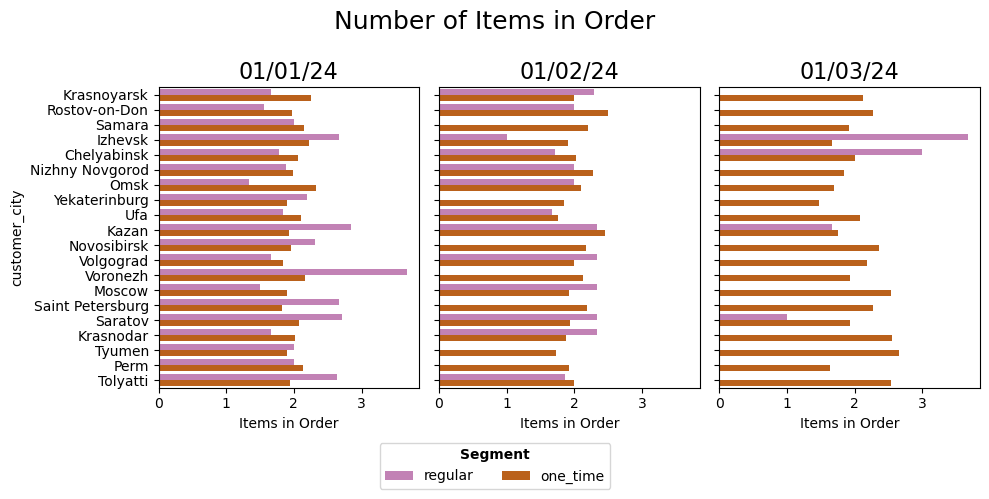

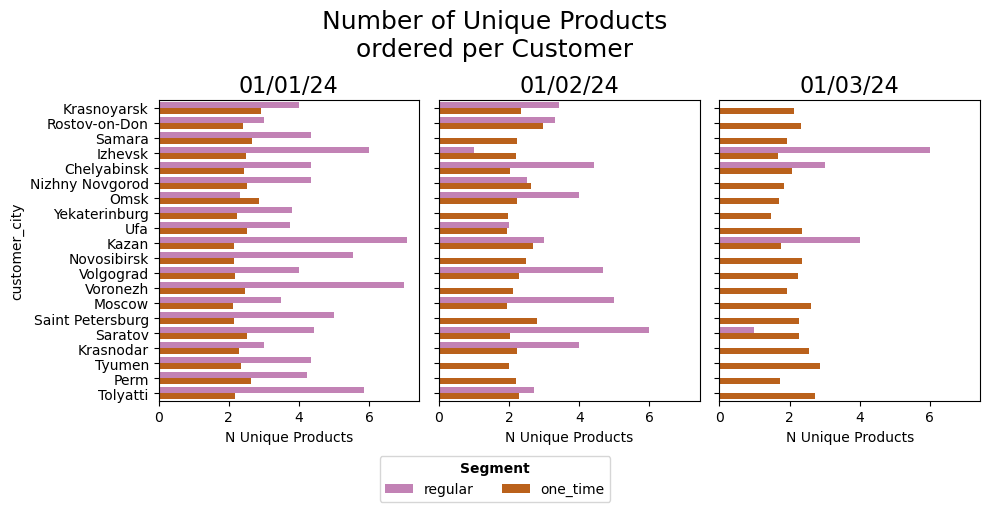

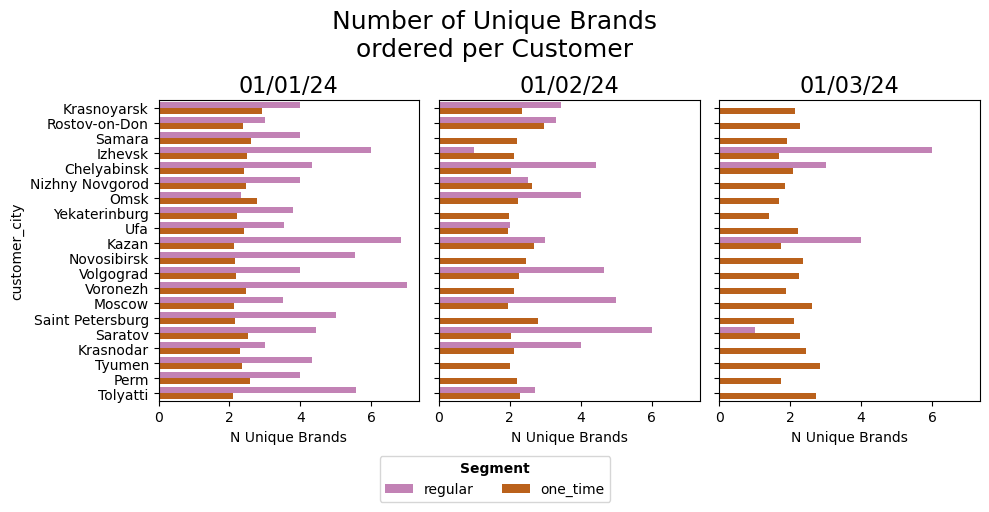

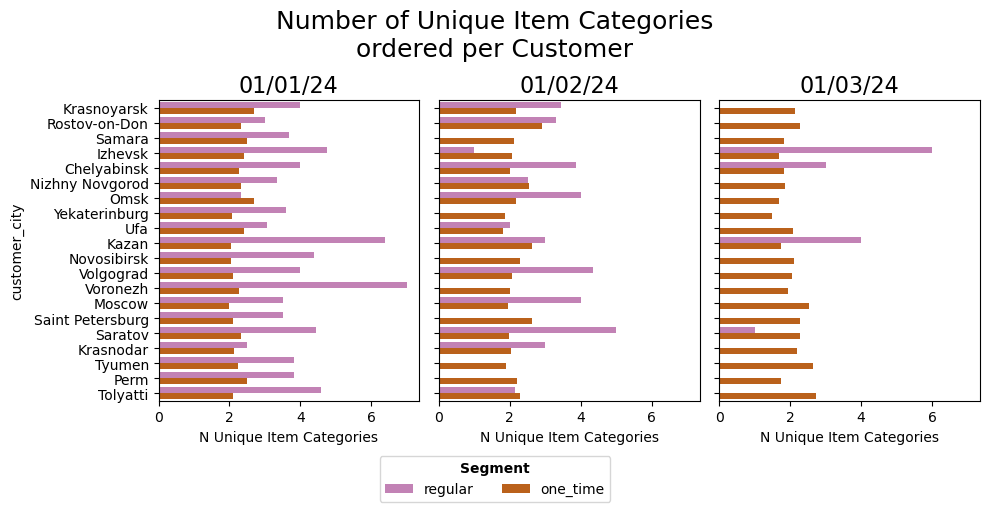

In [27]:
# Plot
all_cities = city_df_not_nan.sort_values('rank_paying_customers_count').customer_city
cohorts = delivered_order_diversity_df.cohort.unique()
segments = ['regular', 'one_time']

numeric_vals = {'order_size':'Number of Items in Order',
      'customers_unique_products_count_total':'Number of Unique Products\nordered per Customer',
      'customers_unique_brands_count_total':'Number of Unique Brands\nordered per Customer',
      'customers_unique_category_count_total':'Number of Unique Item Categories\nordered per Customer'
      }
x_labels = {'order_size':'Items in Order',
      'customers_unique_products_count_total':'N Unique Products',
      'customers_unique_brands_count_total':'N Unique Brands',
      'customers_unique_category_count_total':'N Unique Item Categories'
      }
for num_val, num_name in numeric_vals.items():
    fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)
    for i_coh, coh in enumerate(cohorts):
        dat = delivered_order_diversity_df.loc[
            (delivered_order_diversity_df['cohort'] == coh) &
            (delivered_order_diversity_df['segment'].isin(segments))
        ]

        sns.barplot(
            data=dat, x=num_val, y='customer_city',
            hue='segment', ax=axes[i_coh],
            palette=segment_colors, hue_order=segments,
            order=all_cities,
            errorbar=None
        )
        axes[i_coh].tick_params(labelbottom=True)
        axes[i_coh].set_title(coh, fontsize=16)
        axes[i_coh].set_xlabel(x_labels[num_val])
        
        # keep only one legend for the whole figure
        if i_coh == 0:
            handles, labels = axes[i_coh].get_legend_handles_labels()
        axes[i_coh].get_legend().remove()

    # Legend
    leg = fig.legend(handles, labels, title='Segment', loc='center',
               bbox_to_anchor=(0.5, -0.05), ncol=2)
    leg.get_title().set_fontweight('bold')
    
    fig.text(0.5, 1.06, num_name, fontsize=18, ha='center', va='center')
    plt.tight_layout()
    plt.show()

- Regular customers show substantially higher diversity across all metrics compared to one-time customers. On average, regular customers order from 4 - 7 unique products, brands, and categories over their lifetime, while one-time customers typically order 2 - 3. This is consistent with the revenue difference found earlier and suggests that engagement breadth (not just purchase frequency) distinguishes loyal customers

- Order size (items per order) is similar across both segments, typically 1 - 3 items, indicating that regular customers do not place larger individual orders, they simply place more of them and explore a wider range of the catalogue over time

- At the city level, diversity is broadly consistent, with some notable exceptions. Kazan and Voronezh stand out among regular customers in the January cohort with average category counts exceeding 6, while Omsk and Krasnodar show much lower diversity (2 - 3 categories). However, these city-level differences in diversity do not align clearly with the revenue and redemption rate patterns identified earlier (high-diversity cities are not necessarily high-revenue cities). This suggests that catalogue exploration is driven more by individual customer behaviour than by city-level factors

# Conclusions

This analysis examined the performance of an e-commerce marketplace across three months of data (January - March 2024), covering cohort retention, city-level revenue, customer segmentation, delivery reliability, and order diversity. The central finding is that the marketplace has a solid foundation (retention rates and revenue trends are encouraging) but several operational issues are suppressing revenue and likely damaging customer experience. Addressing these issues should take priority over expanding to new audiences

## What is working

Retention rates are stable at 20–30% across month-1 and month-2, with month-2 frequently exceeding month-1, consistent with a monthly repurchase cycle. Revenue grows predictably with cohort tenure, and spending patterns are consistent across cohorts, indicating a stable and repeatable customer base. High-loyalty cities such as Tolyatti demonstrate that strong product-market fit exists in parts of the market: ~130 customers there generate comparable revenue to Samara, which has 1.5x more customers

## What needs to be fixed first

1. **Delivery delays are a systemic problem that is silently churning customers.** A substantial share of Inactive and One-time customers have orders that are still In Transit, delayed 10 - 40+ days beyond the estimated delivery date. These customers are not disengaged, they are waiting for orders that have not arrived. This is the most urgent issue: unresolved deliveries damage trust and prevent repeat purchases. Any retention or reactivation effort will underperform until this is addressed. The selection bias in the Regular segment reinforces this (customers who receive orders on time are the ones who become loyal buyers)

2. **Most registered customers never make a purchase.** The majority of registered users fall into the Inactive or New segments and have never completed an order. This conversion gap represents the highest-leverage growth opportunity that does not require acquiring new customers. Even a modest improvement in conversion rate would meaningfully increase revenue given the size of this pool

3. **Underperforming cities need diagnosis before investment.** Perm, Saint Petersburg, and Ekaterinburg generate less revenue than their customer counts would predict, with low redemption rates. Delivery speed, lateness, and product assortment are not the cause, as these cities show no elevated delays compared to others. Pricing or stronger local competition are the more likely explanations. These cities should not receive acquisition investment until the root cause is understood

## What to do once the above is resolved

Cohort size is stable at ~150–165 paying customers per month but not growing. With delivery reliability improved and conversion rates higher, scaling acquisition, particularly in high-loyalty cities, is the logical next step. Regular customers already explore 4 - 7 unique products, brands, and categories over their lifetime compared to 2 - 3 for one-time buyers, suggesting that a broader and more engaged customer base would compound revenue significantly over time

## Data limitations

This analysis covers three months of data, which limits the conclusions that can be drawn about long-term retention and cohort behaviour. A minimum of six months would be needed to assess whether retention stabilises or declines over time. Revenue figures are aggregated and city-level sample sizes for some segments are small, particularly for the Regular segment, which should be kept in mind when interpreting city-level findings